Overview 
- Show a simple 3rd order polynomial function (done)
- Fit a polynomial function to the data after sampling (done)
- Manually fit 3 relu-neurons to the data using interactive sliders (done)
- Learn forward and backward propagation and implement it in code for one step of gradient descent for a three neuron network
- Build a complete neural network with one hidden layer and many neurons and train it to learn the function
- Compare with polynomial regression and see how it performs when we add noise to the data.

# Building a neural network from scratch

In this module, you will build a neural network which will learn a very simple function, a polynomial function of the sort: 
y = A + B * x + C * x^2 + D * x^3 

You can choose the value of coefficients for this exercise. Later on we will see what happens when we add noise. 

But first, let us plot and see your function! 

Text(0, 0.5, 'Y')

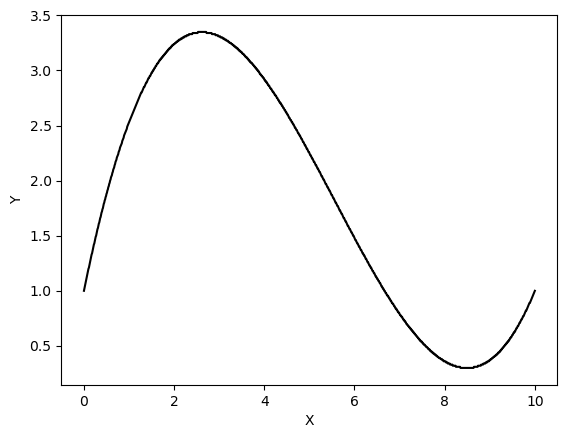

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
A = 1 # np.random.normal(loc=1, scale=0.5, size=1).round(2), 1
B = 2 # np.random.normal(loc=2, scale=0.5, size=1).round(2)
C = -0.5 # np.random.normal(loc=-0.5, scale=0.5, size=1).round(2)
D = 0.03 # np.random.normal(loc=0.04, scale=0.05, size=1).round(2)
x_true = np.linspace(0, 10, 1000).round(2)
y_true = (A + B * x_true + C * x_true**2 + D * x_true**3).round(2)

plt.plot(x_true, y_true, color="black")
plt.xlabel('X')
plt.ylabel('Y')

# Learning from data
The function that you plot above is ofcourse arbitrary, since you chose the coefficients of the polynomial. In fact the choice of a polynomial is also arbitrary (we chose it because it is easy to explain). But in reality this could have a certain meaning; a 1-D function could be a signal from a sensor, for instance a temperature sensor, or it could show how price of a house changes with time, etc. 
(Insert example of a 1-D signal relevant to biology, which is simple like a polynomial)

In reality, you will get only discrete data points from a sensor and you need to build a model from this data. The process of learning the function from a discrete set of points is called Machine Learning. Below, you can see a set of sampled points from the function that you generated above. The sampled points are in red, and the dashed line indicates the true function. 

      X     Y
0  2.25  3.31
1  7.30  0.63
2  8.01  0.36
3  3.78  3.04
4  4.97  2.27


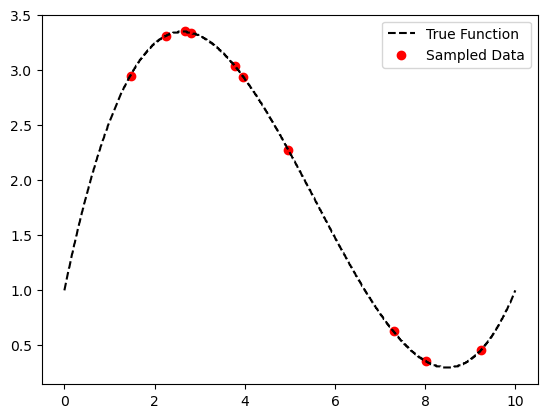

In [2]:
sample_size = 10
sampling_indices = np.random.choice(len(x_true), size=sample_size, replace=False)
x_sample = x_true[sampling_indices]
y_sample = y_true[sampling_indices] 

plt.plot(x_true, y_true, color="black", label="True Function", linestyle='--')
plt.scatter(x_sample, y_sample, color="red", label="Sampled Data")
plt.legend()

# show sampled points as a table 

data = {'X': x_sample, 'Y': y_sample}
df = pd.DataFrame(data)
print(df.head())

A direct method is ofcourse to use a polynomial function. We will use that method to fit the function first. Then, we will build a neural network from scratch and then fit those same datapoints. We will then discuss what the difference is between fitting a polynomial versus a neural network is. 

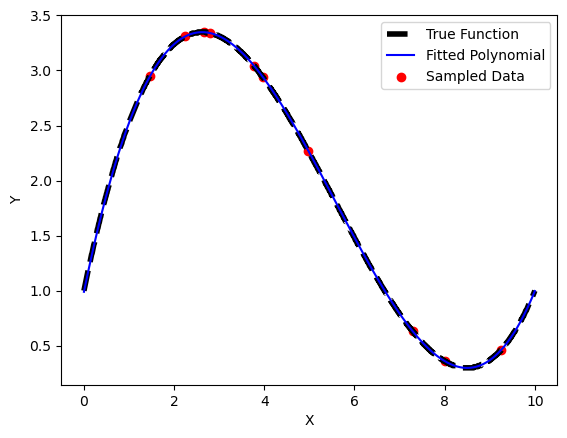

In [3]:
# Fitting a polynomial of degree 3 to the data
coefficients = np.polyfit(x_sample, y_sample, deg=3)
fitted_polynomial = np.poly1d(coefficients)
y_fitted = fitted_polynomial(x_true)
plt.plot(x_true, y_true, color="black", label="True Function", linestyle='--', linewidth=4)
plt.plot(x_true, y_fitted, color="blue", label="Fitted Polynomial")
plt.scatter(x_sample, y_sample, color="red", label="Sampled Data")
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()


# Learning through neurons

We will see in this module how the same function can be learnt through a different framework, one loosely inspired by the human brain. A neuron is simply a cell which takes some input and transforms into an output, and the comparison to biological neuron basically ends there. 

For biological neurons, the transformation of the input is generally described as a binary output (either it fires or not). This can be modelled as a sigmoid function, where the output slowly changes between 0 and 1 through an exponential change. 

A digital neuron can ofcourse be modelled by any mathematical function. Normally, this function is a non-linear function. The simplest non-linear function that is typically used is one which just produces a null output for all negative inputs, and returns the same input if it is positive. It is called a rectified linear function (ReLU). Run the code cell below to see the shape of the two functions 

TODO: Add an interactive cell here to show how neurons modify the input given an activation function

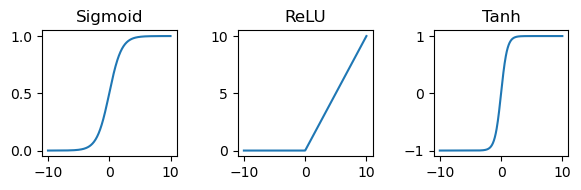

In [4]:
import matplotlib.pyplot as plt
import numpy as np
def activation_function(z, function_type="sigmoid"):
    if function_type == "sigmoid":
        return 1 / (1 + np.exp(-z))
    elif function_type == "relu":
        return np.maximum(0, z)
    elif function_type == "tanh":
        return np.tanh(z)
    elif function_type == "linear":
        return z
    else:
        raise ValueError("Unsupported activation function.")


# plot sigmoid and relu

z = np.linspace(-10, 10, 400)
sigmoid_values = activation_function(z, function_type="sigmoid")
relu_values = activation_function(z, function_type="relu")
tanh_values = activation_function(z, function_type="tanh")
fig, ax = plt.subplots(1, 3, figsize=(6, 2))
ax[0].plot(z, sigmoid_values)
ax[0].set_title("Sigmoid")
ax[1].plot(z, relu_values)
ax[1].set_title("ReLU")
ax[2].plot(z, tanh_values)
ax[2].set_title("Tanh")

plt.tight_layout()



Learning through a neuron network, simply amounts to finding a combination of activation functions which best approximates the dataset that you have provided. In contrast to fitting a polynomial, where you know the type of function that you are approximating, here the prior knowledge required is much less. As you will see, _any_ function can be approximated by a neural network, given enough neurons and layers. 

First, check out what parameters you can change for each activation function type. Let us stick to ReLu for now. 

In [5]:
# Add an interact to visualise effect of parameters on the neuron output
# Use ReLU, PReLU, sigmoid, and tanh as activation functions
import ipywidgets as widgets
def update_neuron_output(slope, bias):
    input = np.array([1])  # Example input
    # Plot the output
    x_global = np.linspace(-10, 10, 400)
    z = slope * x_global + bias
    y_global = activation_function(z, function_type="relu")
    plt.figure(figsize=(3, 3))
    plt.plot(x_global, y_global, label=f"Output")
    plt.plot(x_global, z, color="gray", linestyle='--', label=f"Linear function")
    plt.xlabel('Input (x)')
    plt.ylabel('Output (y)')
    plt.xlim(0, 10)
    plt.xticks(np.arange(-4, 11, 4))
    plt.yticks(np.arange(-5, 11, 5))
    plt.ylim(-5, 10)
    plt.legend()
    plt.title(f"Slope={slope:.2f}, Bias={bias:.2f}")
    
slope_slider = widgets.FloatSlider(min=0, max=5, step=0.1, value=1, description='Slope')
bias_slider = widgets.FloatSlider(min=-5, max=5, step=0.1, value=0, description='Bias')
widgets.interact(update_neuron_output, slope=slope_slider, bias=bias_slider)



interactive(children=(FloatSlider(value=1.0, description='Slope', max=5.0), FloatSlider(value=0.0, description…

<function __main__.update_neuron_output(slope, bias)>

See how the slope and the bias both affect the point at which the function starts to produce a non-zero output. Let us call this as the "activation point" (which is not exactly a technical term, but it is a useful one for our discussion).

Try the next cell to change the ReLU function using slope and activation point. 

In [6]:
# Add an interact to visualise effect of parameters on the neuron output
# Use ReLU, PReLU, sigmoid, and tanh as activation functions
import ipywidgets as widgets
def update_neuron_output_using_activation_point(slope, activation_point):
    input = np.array([1])  # Example input
    # Plot the output
    x_global = np.linspace(-10, 10, 400)
    # calculate bias from activation point
    bias = -slope * activation_point
    z = slope * x_global + bias
    y_global = activation_function(z, function_type="relu")
    plt.figure(figsize=(3, 3))
    plt.plot(x_global, y_global, label=f"Output")
    plt.plot(x_global, z, color="gray", linestyle='--', label=f"Linear function")
    plt.xlabel('Input (x)')
    plt.ylabel('Output (y)')
    plt.xlim(0, 10)
    plt.xticks(np.arange(-4, 11, 4))
    plt.ylim(-5, 10)
    # vertical line at activation point until it hits the bias value
    plt.scatter(0, bias)
    plt.plot([-4, 0], [bias, bias], color="red", linestyle='--')
    # add bias value as y tick
    plt.yticks([-5.0, 0.0, 5.0, 10.0, bias])
    # round off 1 decimal for ytick label
    plt.yticks([-5.0, 0.0, 5.0, 10.0, bias], [f"{-5:.1f}", f"{0:.1f}", f"{5:.1f}", f"{10:.1f}", f"{bias:.1f}"])
    


    plt.legend()
    plt.title(f"Slope={slope:.2f}, Bias={bias:.2f}")
    plt.tight_layout()
    
slope_slider = widgets.FloatSlider(min=0, max=5, step=0.1, value=1, description='Slope')
activation_point_slider = widgets.FloatSlider(min=0, max=8, step=0.1, value=0, description='Activation point')
widgets.interact(update_neuron_output_using_activation_point, slope=slope_slider, activation_point=activation_point_slider)



interactive(children=(FloatSlider(value=1.0, description='Slope', max=5.0), FloatSlider(value=0.0, description…

<function __main__.update_neuron_output_using_activation_point(slope, activation_point)>

Now, combine three ReLU neurons together to see how they can approximate a more complex function. Use activation point, slope and weights to change the shape of the function.

In [7]:
def update_layer_of_neurons_using_slope_activation_point(slope_1, slope_2, slope_3, activation_point_1, activation_point_2, activation_point_3, weight_1, weight_2, weight_3, output_bias):
    # calculate bias from activation points for each neuron
    bias_1 = -slope_1 * activation_point_1
    bias_2 = -slope_2 * activation_point_2
    bias_3 = -slope_3 * activation_point_3
    # combined output
    x_global = np.linspace(-10, 10, 1000)
    z_1_global = slope_1 * x_global + bias_1
    z_2_global = slope_2 * x_global + bias_2
    z_3_global = slope_3 * x_global + bias_3
    y_1_global = activation_function(z_1_global, function_type="relu")
    y_2_global = activation_function(z_2_global, function_type="relu")
    y_3_global = activation_function(z_3_global, function_type="relu")

    combined_output = weight_1 * y_1_global + weight_2 * y_2_global + weight_3 * y_3_global + output_bias
    x_global_true = np.linspace(0, 10, 1000)
    y_1_global_true = activation_function(slope_1 * x_global_true + bias_1, function_type="relu")
    y_2_global_true = activation_function(slope_2 * x_global_true + bias_2, function_type="relu")
    y_3_global_true = activation_function(slope_3 * x_global_true + bias_3, function_type="relu")
    combined_output_true = weight_1 * y_1_global_true + weight_2 * y_2_global_true + weight_3 * y_3_global_true + output_bias

    fig, ax = plt.subplots(1, 4, figsize=(12, 3))
    ax[0].plot(x_global, y_1_global, label=f"Neuron 1 Output")
    ax[0].set_title(f"Neuron 1\nSlope={slope_1:.2f}, Bias={bias_1:.2f}")
    ax[0].set_xlabel('Input (x)')
    ax[0].set_ylabel('Output (y)')
    ax[0].legend()
    ax[0].set_xlim(-4, 10)
    ax[0].set_xticks(np.arange(-4, 11, 4))
    ax[0].set_ylim(-5, 10)
    ax[0].set_yticks(np.arange(-5, 11, 5))
    ax[1].plot(x_global, y_2_global, label=f"Neuron 2 Output")
    ax[1].set_title(f"Neuron 2\nSlope={slope_2:.2f}, Bias={bias_2:.2f}")
    ax[1].set_xlabel('Input (x)')
    # hide y axis for ax[1]
    ax[1].set_ylim(-5, 10)
    ax[1].set_yticks([])
    ax[1].legend()
    ax[1].set_xlim(0, 10)
    ax[1].set_xticks(np.arange(-4, 11, 4))
    ax[2].plot(x_global, y_3_global, label=f"Neuron 3 Output")
    ax[2].set_title(f"Neuron 3\nSlope={slope_3:.2f}, Bias={bias_3:.2f}")
    ax[2].set_xlabel('Input (x)')
    # hide y axis for ax[2]
    ax[2].set_ylim(-5, 10)
    ax[2].set_yticks([])
    ax[2].legend()
    ax[2].set_xlim(0, 10)
    ax[2].set_xticks(np.arange(-4, 11, 4))
    ax[3].plot(x_global, combined_output, label=f"Combined Output")
    ax[3].plot(x_true, y_true, color="black", label="True Function", linestyle='--', linewidth=2)
    ax[3].set_title(f"Combined Output")
    ax[3].set_xlabel('Input (x)')
    # hide y axis for ax[3]
    ax[3].set_ylim(-5, 10)
    ax[3].set_yticks([])
    ax[3].legend()
    ax[3].set_xlim(0, 10)
    ax[3].set_xticks(np.arange(0, 11, 2))

    # compute mean squared error between combined output and true function at the sampled points
    
    mean_squared_error = np.mean((combined_output_true - y_true)**2)
    plt.suptitle(f"Mean Squared Error: {mean_squared_error:.2f}")
    plt.tight_layout()

In [8]:
slopes = [widgets.FloatSlider(min=-5, max=5, step=0.1, value=0, description='Slope 1'),
          widgets.FloatSlider(min=-5, max=5, step=0.1, value=0, description='Slope 2'),
          widgets.FloatSlider(min=-5, max=5, step=0.1, value=0, description='Slope 3')]
activation_points = [widgets.FloatSlider(min=-5, max=8, step=0.1, value=0, description='Activation point 1'),
                     widgets.FloatSlider(min=-5, max=8, step=0.1, value=0, description='Activation point 2'),
                     widgets.FloatSlider(min=-5, max=8, step=0.1, value=0, description='Activation point 3')]
weights = [widgets.FloatSlider(min=-5, max=5, step=0.1, value=1, description='Weight 1'),
              widgets.FloatSlider(min=-5, max=5, step=0.1, value=1, description='Weight 2'),
              widgets.FloatSlider(min=-5, max=5, step=0.1, value=1, description='Weight 3')]

output_bias = widgets.FloatSlider(min=-5, max=5, step=0.1, value=0, description='Output Bias')
widgets.interact(update_layer_of_neurons_using_slope_activation_point, \
                 slope_1=slopes[0], slope_2=slopes[1], slope_3=slopes[2], \
                 activation_point_1=activation_points[0], activation_point_2=activation_points[1], activation_point_3=activation_points[2], \
                 weight_1=weights[0], weight_2=weights[1], weight_3=weights[2], output_bias=output_bias)


interactive(children=(FloatSlider(value=0.0, description='Slope 1', max=5.0, min=-5.0), FloatSlider(value=0.0,…

<function __main__.update_layer_of_neurons_using_slope_activation_point(slope_1, slope_2, slope_3, activation_point_1, activation_point_2, activation_point_3, weight_1, weight_2, weight_3, output_bias)>

Could you get a good fit? Could you get the error to be less than 1? What about 0.1? or even 0.01 or zero?

## Think! 
- Why do you think three neurons were sufficient for this curve? 
- What would happen if you had only two neurons? What if you have a million neurons?


# Artificial Neural Networks

In biological neurons, the connection strengths between the cells are modulated by complex biochemical processes. In artificial neurons, the connection strength is simply a number, which we call a weight. The weight can be positive or negative, and it determines how much influence the input has on the output of the neuron. Each neuron performs a linear combination of the inputs with the weights and then applies the non-linear activation function before sending the output to the next layer of neurons. Mathematically, the output of a single neuron can be expressed as:

\begin{equation}
y = f\left(\sum_{i=1}^{n} w_i x_i + b\right)
\end{equation}

Where:
- $x_i$ are the inputs to the neuron
- $w_i$ are the weights associated with each input, similar to the slope that you just played with
- $b$ is the bias term, which shifts the activation point of the function along with the weights
- $f$ is the activation function (e.g., ReLU, sigmoid)
- $y$ is the output of the neuron

To build this in Python, we will make use of Class objects. In the next code cell, you will see a simply definition of a Neuron class. In the initialisation function, you define a certain parameters. Then, you will different functions defined within a given class called methods. 


In [9]:
class Neuron:
    def __init__(self, weights=None, bias=None, input_vector=None, activation_function_type="relu"):
        self.weights = weights if weights is not None else np.random.normal(0, 1) # initialize weights randomly if not provided
        self.bias = bias if bias is not None else np.random.normal(0, 1)
        self.input_vector = input_vector if input_vector is not None else np.random.normal(0, 1, size=(5,)) # initialize input vector randomly if not provided
        self.activation_function_type = activation_function_type



Nice. In the next cell, you will see a new method called "forward". This method takes an input and produces an output by applying the weights, bias and activation function. We will inherit the Neuron class that was already defined. So you would have to run the previous code cell before you can run the next one.


In [10]:
class Neuron(Neuron):
    def forward(self):
        z = np.dot(self.weights, self.input_vector) + self.bias
        output = activation_function(z, function_type=self.activation_function_type)
        output = output.squeeze()  # Remove any extra dimensions
        return output

In [11]:
n1 = Neuron(
    input_vector = np.array([1, 2, 3]), 
    weights = np.array([0.5, 3.2, -0.5]), 
    bias = np.array([0.1]),
    activation_function_type = 'relu'
)

output = n1.forward()

print(f"Output of the neuron: {output} for input vector {n1.input_vector}, weights {n1.weights}, and bias {n1.bias}")

Output of the neuron: 5.5 for input vector [1 2 3], weights [ 0.5  3.2 -0.5], and bias [0.1]


Next, we will define a layer of neurons. Each layer has a certain number of neurons and commonly they all share the same activation function. The output of one layer is the input to the next layer. The first layer is called the input layer, and the last layer is called the output layer. The layers in between are called hidden layers.


In [12]:
class Layer:
    def __init__(self, layer_type):
        self.neurons = []
        self.forward_layer = None # to store the output of the layer in the forward pass
        self.backward_layer = None # to store the gradient of the layer in the backward pass
        self.layer_type = layer_type # allowed "input", "hidden", "output"
    def add_neuron(self, neuron):
        # to add single neuron to the layer
        self.neurons.append(neuron)
    def add_neurons(self, neurons):
        # to add multiple neurons to the layer
        self.neurons.extend(neurons)
    

Now, we will add a forward method for the layer to combine the outputs of all the neurons in the layer. The size of the output of the layer will depend on the number of neurons in that layer. 


In [13]:
class Layer(Layer):
    def __init__(self, layer_type):
        super().__init__(layer_type)
        self.outputs = [] # adds a new attribute to store the outputs of the neurons in the layer
    def forward(self):
        if self.layer_type != "input":
            self.backward_layer.forward()
        outputs = []
        for neuron in self.neurons:
            output = neuron.forward()
            outputs.append(output)
        
        outputs = np.array(outputs).T
        #outputs = outputs.squeeze() 
        self.outputs = outputs
        return outputs

Let us build an input layer with 1 neuron. Use the next code cell to instantiate a layer with 1 neuron. Use the inputs from sampled data points from before to initialize the input layer.

In [14]:
# Start with the first input point from the sampled data. 
input_vector = np.array([x_sample[0]])
output_vector = np.array([y_sample[0]])
print(f"The input is {input_vector} and the expected output is {output_vector}")

The input is [2.25] and the expected output is [3.31]


In [15]:
input_layer = Layer(layer_type="input")
input_layer.add_neuron(
    Neuron(
        input_vector = input_vector, 
        weights = np.array([1]),
        bias = 0, 
        activation_function_type = 'linear'
    )
)
input_layer.forward()


array([2.25])

The layers between the input and output layer are called hidden layers. We will use a single hidden layer which has three neurons. Choose your own weights and bias vectors for this hidden layer. Take care to match the dimensions of these parameters! 

In [16]:
hidden_layer_1 = Layer("hidden")
hidden_layer_1.backward_layer = input_layer
hidden_layer_1.add_neurons([
    Neuron(
        input_vector = input_layer.forward(), 
        weights = np.array([0.1]),
        bias = np.array([0.5]),
        activation_function_type = 'relu'
    ),
    Neuron(
        input_vector = input_layer.forward(), 
        weights = np.array([1.5]),
        bias = np.array([-0.3]),
        activation_function_type = 'relu'
    ),
    Neuron(
        input_vector = input_layer.forward(), 
        weights = np.array([-0.3]),
        bias = np.array([0]),
        activation_function_type = 'relu'
    )
])

hidden_layer_1.forward()

array([0.725, 3.075, 0.   ])

In [17]:

hidden_layer_output = hidden_layer_1.forward()

print("Output of the layer:", hidden_layer_output)

Output of the layer: [0.725 3.075 0.   ]


Now, we need to combine these neurons into a single output neuron. This will be our final layer. Here, we have one neuron which takes three inputs, which are the outputs of the three neurons in the previous layer. The neuron in this layer will normally have linear activation function, which means that it will simply sum the inputs with the weights and bias without applying any non-linearity.


In [18]:
final_layer = Layer("output")
hidden_layer_1.forward_layer = final_layer 
final_layer.backward_layer = hidden_layer_1
final_layer.add_neuron(
    Neuron(
        input_vector = hidden_layer_1.forward(),
        weights = np.array([0.2, -0.8, 0]), 
        bias = np.array([0.1]),
        activation_function_type = 'linear'
    )
)

final_output = final_layer.forward()
print(f"Final output of the network: {final_output} for input vector {input_vector} and expected output {output_vector}")

Final output of the network: [-2.215] for input vector [2.25] and expected output [3.31]


Is there a lot of error? Well, that is life... We will now start learning how to correct our mistakes! As in life, the first step is to acknowledge the error. In deep learning, we do it with something called as a "loss function". It tells you how far your predictions are from the expected outcome. 

In case of regression problems (like the one we are working on), a common loss function is the Mean Squared Error (MSE), which is calculated as:
\begin{equation}
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
\end{equation}
Where:
- $y_i$ are the true values
- $\hat{y}_i$ are the predicted values from the neural network
- $n$ is the number of data points in the output
There are other loss functions as well. Try to implement the MSE loss function and calculate the loss for your current model.


In [19]:
# Compute the loss 
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

In [20]:
loss_value = mean_squared_error(output_vector, final_output)
print("Loss value:", loss_value)

Loss value: 30.525625000000005


It's great that you now know exactly how wrong you were! Now, time to correct it. 

# Backpropagation

Here, we calculate the gradient of the loss function with respect to each weights and bias in the neural network. This might seem complicated because there are many parameters. However, we will how the chain rule of calculus comes in handy. 

But first, we will start with a simpler problem. We will calculate the derivative of the loss function with respect to the final output of the network. This is the first step in backpropagation. First, recap the equation for the MSE for a single data point:


\begin{equation}
MSE = (y_i - \hat{y}_i)^2
\end{equation}


\begin{equation}
\frac{\partial MSE}{\partial \hat{y}_{final}} = \delta_{out} = -2(y_i - \hat{y}_i) 
\end{equation}

The term $\delta_{out}$ is called the output error signal, and it tells us how much the final output of the network is contributing to the error.

In [21]:
def gradient_mse(y_true, y_pred):
    return 2 * (y_pred - y_true) / len(y_true)

output_error_signal = gradient_mse(output_vector, final_output)

print("Output error signal:", output_error_signal)


Output error signal: [-11.05]


In [22]:
def plot_loss_landscape_with_state(loss_fn, output_vector, states=None, window_size=100, tangent=None, \
                                   show_legend=True, figsize=(5,3)):
    import matplotlib.pyplot as plt 
    import matplotlib.cm as cm 
    # ignore warnings
    import warnings
    warnings.filterwarnings("ignore")

    y_pred_around_output = np.linspace(output_vector-window_size, output_vector+window_size, 1000)
    loss_values = [loss_fn(output_vector, y_pred) for y_pred in y_pred_around_output]
    plt.figure(figsize=figsize)
    plt.plot(y_pred_around_output, loss_values)
    plt.xlabel("Predicted values")
    plt.ylabel("Loss")

    # Add points
    if states is not None:
        colors = cm.get_cmap('viridis', len(states))
        for i, state in enumerate(list(states.values())):
            plt.scatter(state['prediction'], state['loss'], label=state['condition'], color=colors(i))

    if tangent is not None:
        # tangent = slope
        tangent_line = tangent['slope'] * y_pred_around_output + (tangent['loss'] - tangent['slope'] * tangent['prediction'])
        plt.plot(y_pred_around_output, tangent_line, color="gray", \
                 linestyle="--", label=r'$\delta_{out}$' + '={:.2f}'.format(tangent['slope']))
    
    plt.ylim(-200, max(loss_values)*1.1)
    if show_legend:
        plt.legend()
        

def print_summary_of_network(**layers):
    import pandas as pd
    df = pd.DataFrame(columns=["Layer", "Neuron", "Weights", "Bias", "Activation Function", "Input Vector", "Output"])
    for layer_name, layer in layers.items():
        df_layer = pd.DataFrame(columns=["Layer", "Neuron", "Weights", "Bias", "Activation Function", "Input Vector", "Output"])
        df_layer["Layer"] = [layer_name] * len(layer.neurons)
        df_layer["Neuron"] = [f"Neuron {i+1}" for i in range(len(layer.neurons))]
        df_layer["Weights"] = [neuron.weights for neuron in layer.neurons]
        df_layer["Bias"] = [neuron.bias for neuron in layer.neurons]
        df_layer["Activation Function"] = [neuron.activation_function_type for neuron in layer.neurons]
        df_layer["Input Vector"] = [neuron.input_vector for neuron in layer.neurons]
        df_layer["Output"] = [neuron.forward() for neuron in layer.neurons]
        df = pd.concat([df, df_layer], ignore_index=True)
    
    # round the weights, bias, input vector and output to 2 decimal places for better display
    df["Weights"] = df["Weights"].apply(lambda x: np.round(x, 2) if isinstance(x, np.ndarray) else x)
    df["Bias"] = df["Bias"].apply(lambda x: np.round(x, 2) if isinstance(x, np.ndarray) else x)
    df["Input Vector"] = df["Input Vector"].apply(lambda x: np.round(x, 2) if isinstance(x, np.ndarray) else x)
    df["Output"] = df["Output"].apply(lambda x: np.round(x, 2) if isinstance(x, np.ndarray) else x)
    
    print(df)

        # print("-" * 20)
        # print(f"Layer: {layer_name}")
        # print("-" * 20)
        # for i, neuron in enumerate(layer.neurons):
        #     print(f" Neuron {i+1}:")
        #     print(f"    Weights: {neuron.weights}", end=" | ")
        #     print(f"    Bias: {neuron.bias}", end=" | ")
        #     print(f"    Activation Function: {neuron.activation_function_type}", end=" | ")
        #     print(f"    Input Vector: {neuron.input_vector}", end=" | ")
        #     print(f"    Output: {neuron.forward()}")


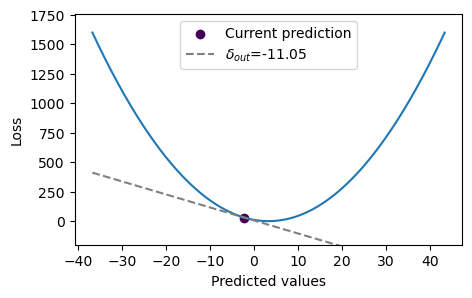

In [23]:
states = {
    'Current prediction' : {
        'prediction': final_output[0],
        'loss': loss_value,
        'condition': 'Current prediction',
        'slope' : output_error_signal[0]
    },
}

plot_loss_landscape_with_state(
    mean_squared_error, output_vector[0], \
    states=states, tangent=states['Current prediction'], window_size=40
)

In [24]:
print_summary_of_network(Input_layer=input_layer, Hidden_layer_1=hidden_layer_1, Final_layer=final_layer)

            Layer    Neuron           Weights    Bias Activation Function  \
0     Input_layer  Neuron 1               [1]       0              linear   
1  Hidden_layer_1  Neuron 1             [0.1]   [0.5]                relu   
2  Hidden_layer_1  Neuron 2             [1.5]  [-0.3]                relu   
3  Hidden_layer_1  Neuron 3            [-0.3]     [0]                relu   
4     Final_layer  Neuron 1  [0.2, -0.8, 0.0]   [0.1]              linear   

        Input Vector  Output  
0             [2.25]    2.25  
1             [2.25]    0.72  
2             [2.25]    3.08  
3             [2.25]    0.00  
4  [0.72, 3.08, 0.0]   -2.22  


Let us add the gradient calculation as part of the Neuron class as methods. We can create a "forward_gradient" as a new initialisation parameter and store it for later use. Then we will add a new method called "backward" which will calculate teh gradient of the output of that neuron with respect to its weights and bias. 


In [25]:
class Neuron(Neuron):
    def __init__(self, weights=None, bias=None, input_vector=None, activation_function_type="relu"):
        super().__init__(weights, bias, input_vector, activation_function_type)
        self.forward_gradient = None # to store the gradient of the neuron it connects to in the forward pass
        self.backward_gradient = None # to help the gradient of the neuron it connects to in the backward pass
        
    def relu_derivative(self, z):
        return np.where(z > 0, 1, 0).squeeze()
    
    def backward(self):
        # compute the gradient of the output of this neuron with respect to its weights and bias using the chain rule
        all_weights = np.array(self.weights)
        all_inputs = np.array(self.input_vector)
        
        dy_dw = []
        dyi_dy = []
        for i, x_input in enumerate(all_inputs):
            # reshape weights and inputs to ensure they are 1D arrays for dot product if they are not already
            z = np.dot(all_weights, all_inputs) + self.bias
            if self.activation_function_type == 'relu':
                dy_dz = self.relu_derivative(z)
            elif self.activation_function_type == 'linear':
                dy_dz = 1
            else:
                raise ValueError("Unsupported activation function for backward pass.")
            dz_dw = x_input
            dz_dx = all_weights[i]
            dy_dw.append(dy_dz * dz_dw)
            dyi_dy.append(dy_dz * dz_dx) # backward gradient

        dy_db = self.relu_derivative(z) * 1

        dL_dw = self.forward_gradient * np.array(dy_dw)
        dL_db = self.forward_gradient * dy_db
        dL_dy = self.forward_gradient * np.array(dyi_dy)

        self.gradient_wrt_weights = np.array(dL_dw) 
        self.gradient_wrt_bias = np.array(dL_db)
        self.backward_gradient = np.array(dL_dy)


In [26]:
class Layer(Layer):
    def backward(self):
        for i, neuron in enumerate(self.neurons):
            if self.layer_type == "hidden":
                neuron.forward_gradient = self.forward_layer.neurons[0].backward_gradient[i]
            elif self.layer_type == "output":
                neuron.forward_gradient = self.forward_layer[0] # this will be the output error signal
            else:
                raise TypeError("Layer type has to be hidden or output to call .backward() method")
        
            neuron.backward()
            


Add a method to the Layer class to link each layer to the next layer. This will allow us to propagate the error signal back through the network.


In [27]:
# Update the neurons in all layers to take the latest class definition
for layer in [input_layer, hidden_layer_1, final_layer]:
    layer.__class__ = Layer
    for neuron in layer.neurons:
        neuron.__class__ = Neuron


In [28]:
# Upgrade gradient information in all the layers
final_layer.forward_layer = output_error_signal
final_layer.backward()
hidden_layer_1.backward()

The information that updates all the parameters of the neural network starts from that slope. We use that slope to find the gradients of the loss function with respect to the weights and biases of the network. 

The next set of parameters concerns the output neuron. The forward pass of the output neuron is 

\begin{equation}
\hat{y}_{final} = w_1 y_1 + w_2 y_2 + w_3 y_3 + b
\end{equation}

Where $y_1$, $y_2$ and $y_3$ are the outputs of the three neurons in the previous layer. Note that the output of the final neuron has a linear activation function. 

\begin{equation}
\frac{\partial \hat{y}_{final}}{\partial w_1} = y_1 
\end{equation}

\begin{equation}
\frac{\partial \hat{y}_{final}}{\partial w_2} = y_2
\end{equation}

\begin{equation}
\frac{\partial \hat{y}_{final}}{\partial w_3} = y_3
\end{equation}

\begin{equation}
\frac{\partial \hat{y}_{final}}{\partial b} = 1
\end{equation}
Now, we can use the chain rule to calculate the gradient of the loss function with respect to the weights and bias of the output neuron. For example, for weight $w_1$, we have:



\begin{equation}
\begin{aligned}
\frac{\partial MSE}{\partial w_1} &= \frac{\partial MSE}{\partial \hat{y}_{final}} \cdot \frac{\partial \hat{y}_{final}}{\partial w_1} = \delta_{out} \cdot y_1 \\
\frac{\partial MSE}{\partial w_2} &= \frac{\partial MSE}{\partial \hat{y}_{final}} \cdot \frac{\partial \hat{y}_{final}}{\partial w_2} = \delta_{out} \cdot y_2 \\
\frac{\partial MSE}{\partial w_3} &= \frac{\partial MSE}{\partial \hat{y}_{final}} \cdot \frac{\partial \hat{y}_{final}}{\partial w_3} = \delta_{out} \cdot y_3 \\
\frac{\partial MSE}{\partial b} &= \frac{\partial MSE}{\partial \hat{y}_{final}} \cdot \frac{\partial \hat{y}_{final}}{\partial b} = \delta_{out}
\end{aligned}
\end{equation}

Now, write the code to calculate the gradients for the weights and bias of the output neuron. 







In [29]:
print_summary_of_network(Input_layer=input_layer, Hidden_layer_1=hidden_layer_1, Final_layer=final_layer)

            Layer    Neuron           Weights    Bias Activation Function  \
0     Input_layer  Neuron 1               [1]       0              linear   
1  Hidden_layer_1  Neuron 1             [0.1]   [0.5]                relu   
2  Hidden_layer_1  Neuron 2             [1.5]  [-0.3]                relu   
3  Hidden_layer_1  Neuron 3            [-0.3]     [0]                relu   
4     Final_layer  Neuron 1  [0.2, -0.8, 0.0]   [0.1]              linear   

        Input Vector  Output  
0             [2.25]    2.25  
1             [2.25]    0.72  
2             [2.25]    3.08  
3             [2.25]    0.00  
4  [0.72, 3.08, 0.0]   -2.22  


Now, let us update the weights and bias of only the output neuron using the gradients that we just calculated. We will use a simple update rule called gradient descent, which updates the parameters in the direction of the negative gradient. The update rule is given by:

\begin{equation}
\begin{aligned}
w_i &\leftarrow w_i - \eta \cdot \frac{\partial MSE}{\partial w_i} \\
&\text{for i = 1, 2, 3} \\
b &\leftarrow b - \eta \cdot \frac{\partial MSE}{\partial b}
\end{aligned}
\end{equation}

Where $\eta$ is the learning rate, which determines how much we update the parameters in each iteration. In the next code cell, we will add a new method to the Neuron class called "udpate" which will take the learning rate, and the derivative of the loss function with respect to its weights and bias as input and update them. 



In [30]:
class Neuron(Neuron):
    def update(self, learning_rate=0.01):
        # update weights and bias based on the loss gradient and learning rate 
        self.weights = self.weights - learning_rate * self.gradient_wrt_weights
        self.bias = self.bias - learning_rate * self.gradient_wrt_bias

class Layer(Layer):
    def update(self, learning_rate=0.01):
        for neuron in self.neurons:
            neuron.update(learning_rate)

In [31]:
# Upgrade all layer and neuron instances to the latest class definitions
for layer in [input_layer, hidden_layer_1, final_layer]:
    layer.__class__ = Layer
    for neuron in layer.neurons:
        neuron.__class__ = Neuron

Now, update the weights and bias of the output neuron using the gradients that we calculated. After updating, calculate the new loss and see if it has decreased.

In [32]:
learning_rate = 0.001

In [33]:
final_layer.update(learning_rate=learning_rate)
hidden_layer_1.update(learning_rate=learning_rate)


Did the loss decrease after the update? If not, try to adjust the learning rate and see if it helps.

What happens if you keep on increasing the learning rate? 

Now let us also calculate the gradients for the weights and biases of the three neurons in the previous layer. The forward pass for each of these neurons is given by:
\begin{equation}
\begin{aligned}
y_1 &= f(w_{1-1} x + b_{1-1}) = f(z_1) \\
y_2 &= f(w_{2-1} x + b_{2-1}) = f(z_2) \\
y_3 &= f(w_{3-1} x + b_{3-1}) = f(z_3)
\end{aligned}
\end{equation}

Where $f$ is the activation function (ReLU in our case). To make the text simpler, let us denote the input to the activation function for each neuron as $z_i = w_{i-1} x + b_{i-1}$, where $i$ is the index of the neuron (1, 2, or 3). We will also show the equation for the first neuron only. 

Derivative of the $y_1$ with respect to its parameters is given by:
\begin{equation}
\begin{aligned}
\frac{\partial y_1}{\partial w_{1-1}} &= \frac{\partial y_1}{\partial z_1} \cdot \frac{\partial z_1}{\partial w_{1-1}} \\
\frac{\partial y_1}{\partial b_{1-1}} &= \frac{\partial y_1}{\partial z_1} \cdot \frac{\partial z_1}{\partial b_{1-1}} 
\end{aligned}
\end{equation}

Now, we need to calculate the derivative of the activation function with respect to its input $z_1$. The derivative of the activation function can be represented by the symbol $f'$. For ReLU, the derivative is given by:
For ReLU, the derivative is given by:

\begin{equation}
f'_1 = \frac{\partial y_1}{\partial z_1} = 
\begin{cases}
1 & \text{if } z_1 > 0 \\
0 & \text{if } z_1 \leq 0
\end{cases}
\end{equation}

This gives, 
\begin{equation}
\begin{aligned}
\frac{\partial y_1}{\partial w_{1-1}} &= \frac{\partial y_1}{\partial z_1} \cdot \frac{\partial z_1}{\partial w_{1-1}} = f'_1 \cdot x \\
\frac{\partial y_1}{\partial b_{1-1}} &= \frac{\partial y_1}{\partial z_1} \cdot \frac{\partial z_1}{\partial b_{1-1}} = f'_1 \cdot 1
\end{aligned}
\end{equation}

What is the derivative of the output value $\hat{y}_{final}$ with respect to the output of the first neuron $y_1$?
\begin{equation}
\frac{\partial \hat{y}_{final}}{\partial y_1} = w_1
\end{equation}
Now, we can use the chain rule to calculate the gradient of the loss function with respect to the weights and bias of the first neuron. For example, for weight $w_{1-1}$, we have:

\begin{equation}
\begin{aligned}
\frac{\partial MSE}{\partial w_{1-1}} &= \frac{\partial MSE}{\partial \hat{y}_{final}} \cdot \frac{\partial \hat{y}_{final}}{\partial y_1} \cdot \frac{\partial y_1}{\partial w_{1-1}} \\
&= \delta_{out} \cdot w_1 \cdot f'_1 \cdot x
\end{aligned}
\end{equation}
and for bias $b_{1-1}$, we have:
\begin{equation}
\begin{aligned}
\frac{\partial MSE}{\partial b_{1-1}} &= \frac{\partial MSE}{\partial \hat{y}_{final}} \cdot \frac{\partial \hat{y}_{final}}{\partial y_1} \cdot \frac{\partial y_1}{\partial b_{1-1}} \\
&= \delta_{out} \cdot w_1 \cdot f'_1 
\end{aligned}
\end{equation}
Now, write the code to calculate the gradients for the weights and bias of the first neuron.


In [34]:
print_summary_of_network(Input_layer=input_layer, Hidden_layer_1=hidden_layer_1, Final_layer=final_layer)

            Layer    Neuron             Weights     Bias Activation Function  \
0     Input_layer  Neuron 1                 [1]        0              linear   
1  Hidden_layer_1  Neuron 1               [0.1]    [0.5]                relu   
2  Hidden_layer_1  Neuron 2              [1.48]  [-0.31]                relu   
3  Hidden_layer_1  Neuron 3              [-0.3]    [0.0]                relu   
4     Final_layer  Neuron 1  [0.21, -0.77, 0.0]    [0.1]              linear   

        Input Vector  Output  
0             [2.25]    2.25  
1             [2.25]    0.74  
2             [2.25]    3.02  
3             [2.25]    0.00  
4  [0.72, 3.08, 0.0]   -2.10  


In [35]:
hidden_layer_output_after_update = hidden_layer_1.forward()  
final_output_after_hidden_update = final_layer.forward()


In [36]:
print_summary_of_network(Input_layer=input_layer, Hidden_layer_1=hidden_layer_1, Final_layer=final_layer)

            Layer    Neuron             Weights     Bias Activation Function  \
0     Input_layer  Neuron 1                 [1]        0              linear   
1  Hidden_layer_1  Neuron 1               [0.1]    [0.5]                relu   
2  Hidden_layer_1  Neuron 2              [1.48]  [-0.31]                relu   
3  Hidden_layer_1  Neuron 3              [-0.3]    [0.0]                relu   
4     Final_layer  Neuron 1  [0.21, -0.77, 0.0]    [0.1]              linear   

        Input Vector  Output  
0             [2.25]    2.25  
1             [2.25]    0.74  
2             [2.25]    3.02  
3             [2.25]    0.00  
4  [0.72, 3.08, 0.0]   -2.10  


In [37]:

updated_loss_value_after_hidden_update = mean_squared_error(output_vector, final_output_after_hidden_update)


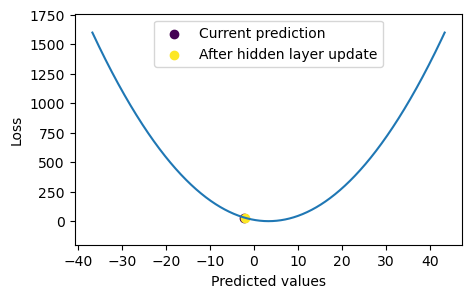

In [38]:
# show the loss landscape around the new prediction point after updating the weights 
states.update({
    'Updated prediction after hidden layer update' : {
        'prediction': final_output_after_hidden_update[0],
        'loss': updated_loss_value_after_hidden_update,
        'condition': 'After hidden layer update',
        'slope' : gradient_mse(output_vector, final_output_after_hidden_update)[0]
    },
})
plot_loss_landscape_with_state(
    mean_squared_error, output_vector[0], \
    states=states, show_legend=True, window_size=40
)

In [39]:
n_iter = 50
for i in range(n_iter):
    # Forward pass
    hidden_layer_output = hidden_layer_1.forward()
    final_output = final_layer.forward()

    # Compute loss and error signal
    loss_value = mean_squared_error(output_vector, final_output)
    output_error_signal = gradient_mse(output_vector, final_output)

    # Backward pass
    final_layer.forward_layer = output_error_signal
    final_layer.backward()
    hidden_layer_1.backward()

    # Update weights and bias
    final_layer.update(learning_rate=learning_rate)
    hidden_layer_1.update(learning_rate=learning_rate)
    
    states.update({
        f'Iteration {i+1} prediction' : {
            'prediction': final_output[0],
            'loss': loss_value,
            'condition': f'Iteration {i+1}',
            'slope' : gradient_mse(output_vector, final_output)[0]
        },
    })


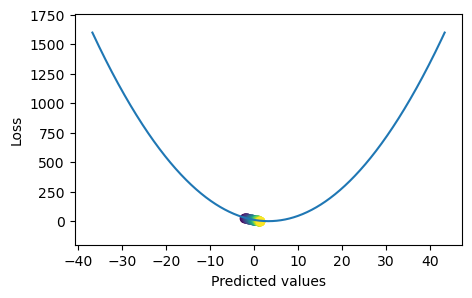

In [40]:
plot_loss_landscape_with_state(
    mean_squared_error, output_vector[0], \
    states=states, show_legend=False, window_size=40
)

So far, we have only calculated using just one data point. How would you calculate the gradients for the entire dataset? We need one more class to combine all layers and perform the forward and backward pass for the entire network. This class is called the NeuralNetwork class. 

In [41]:
class NeuralNetwork:
    def __init__(self, layers):
        self.layers = layers
        self.learning_rate = 0.01
    def forward(self, input_vector):
        current_input = input_vector
        for layer in self.layers:
            if layer.layer_type == "input":
                layer.neurons[0].input_vector = current_input
            else:
                for neuron in layer.neurons:
                    neuron.input_vector = current_input
            current_input = layer.forward()
        return current_input
    

    

In [42]:
nn_simple = NeuralNetwork(layers=[input_layer, hidden_layer_1, final_layer])
nn_output = nn_simple.forward(input_vector)
print(f"Output of the neural network: {nn_output} for input vector {input_vector} and expected output {output_vector}")


Output of the neural network: [1.58564726] for input vector [2.25] and expected output [3.31]


In [43]:
class NeuralNetwork(NeuralNetwork):
    def __init__(self, layers):
        super().__init__(layers)
        self.output_error_signal = None
                    
    def backward(self):
        self.layers[-1].forward_layer = self.output_error_signal
        for layer in reversed(self.layers):
            if layer.layer_type != "input":
                layer.backward()
    def update(self, learning_rate=0.01):
        for layer in self.layers:
            if layer.layer_type != "input":
                layer.update(learning_rate)


In [44]:
nn_simple.__class__ = NeuralNetwork

In [45]:
nn_simple.output_error_signal = output_error_signal
nn_simple.backward()
nn_simple.update(learning_rate=learning_rate)
nn_output = nn_simple.forward(input_vector)
print(f"Output of the neural network after one backward and update step:\n {nn_output} for input vector {input_vector} and expected output {output_vector}")

Output of the neural network after one backward and update step:
 [1.62804794] for input vector [2.25] and expected output [3.31]


In [46]:
class NeuralNetwork(NeuralNetwork):
    def __init__(self, layers):
        super().__init__(layers)
        self.loss_history = []
        self.x_data = None
        self.y_data = None

    def train_one_epoch(self):
        # Train the neural network on the provided data for one epoch
        running_loss = 0
        for x, y in zip(self.x_data, self.y_data):
            # Prepare one input-output pair for training
            input_vector = np.array([x])
            output_vector = np.array([y])

            # Apply the forward pass to get the predicted output
            predicted_output = self.forward(input_vector)

            # Calculate the loss and output error signal 
            loss_value = mean_squared_error(output_vector, predicted_output)
            output_error_signal = gradient_mse(output_vector, predicted_output)
        

            # Start the backward pass and update weights and biases
            self.output_error_signal = output_error_signal
            self.backward()
            self.update(learning_rate=learning_rate)
            running_loss += loss_value
        running_loss /= len(self.x_data)
        self.loss_history.append(running_loss)
        
    def fit(self, x_data, y_data, epochs):
        import numpy as np
        shuffle_indices = np.random.permutation(len(x_data))
        self.x_data = x_data[shuffle_indices]
        self.y_data = y_data[shuffle_indices]
        
        for epoch in range(epochs):
            self.train_one_epoch()
            if self.loss_history[-1] < 1e-5:
                print(f"Stopping training at epoch {epoch+1} as loss has reached below 1e-3")
                break

            

In [74]:
# Create a new instance of the neural network with the same architecture but re-initialized weights and biases
if "input_layer_new" in locals():
    del input_layer_new
    del hidden_layer_1_new 
    del final_layer_new
    print("Deleted previous layer instances to create new ones with re-initialized weights and biases.")


input_layer_new = Layer(layer_type="input")
input_layer_new.add_neuron(
    Neuron(
        input_vector = np.random.normal(0, 1, size=(1,)), 
        weights = np.array([1]),
        bias = np.array([0]),
        activation_function_type = 'linear'
    )
)
hidden_layer_1_new = Layer("hidden")
hidden_layer_1_new.add_neurons([
    Neuron(
        input_vector = np.random.normal(0, 1, size=(1,)),
        weights = np.random.normal(0, 0.1, size=(1,)),
        bias = np.random.normal(0, 0.1),
        activation_function_type = 'relu'
    ),
    Neuron(
        input_vector = np.random.normal(0, 1, size=(1,)),
        weights = np.random.normal(0, 0.1, size=(1,)),
        bias = np.random.normal(0, 0.1),
        activation_function_type = 'relu'
    ),
    Neuron(
        input_vector = np.random.normal(0, 1, size=(1,)),
        weights = np.random.normal(0, 0.1, size=(1,)),
        bias = np.random.normal(0, 0.1),
        activation_function_type = 'relu'
    )
])
final_layer_new = Layer("output")
final_layer_new.add_neuron(
    Neuron(
        input_vector = np.random.normal(0, 1, size=(3,)),
        weights = np.random.normal(0, 0.1, size=(3,)),
        bias = np.random.normal(0, 0.1),
        activation_function_type = 'linear'
    )
)


Deleted previous layer instances to create new ones with re-initialized weights and biases.


In [75]:
# Define connections between layers
input_layer_new.forward_layer = hidden_layer_1_new
hidden_layer_1_new.backward_layer = input_layer_new
hidden_layer_1_new.forward_layer = final_layer_new
final_layer_new.backward_layer = hidden_layer_1_new


In [76]:
my_neural_network = NeuralNetwork(layers=[input_layer_new, hidden_layer_1_new, final_layer_new])

In [77]:
my_neural_network.learning_rate = 0.001
x_sample_mean, x_sample_std = np.mean(x_sample), np.std(x_sample)
y_sample_mean, y_sample_std = np.mean(y_sample), np.std(y_sample)
x_sample_standardized = (x_sample - x_sample_mean) / x_sample_std
y_sample_standardized = (y_sample - y_sample_mean) / y_sample_std
my_neural_network.fit(x_sample_standardized, y_sample_standardized, epochs=5000)




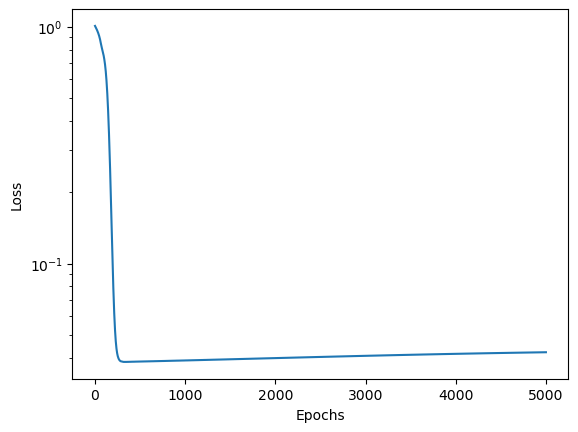

In [78]:
plt.plot(my_neural_network.loss_history)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.yscale("log")

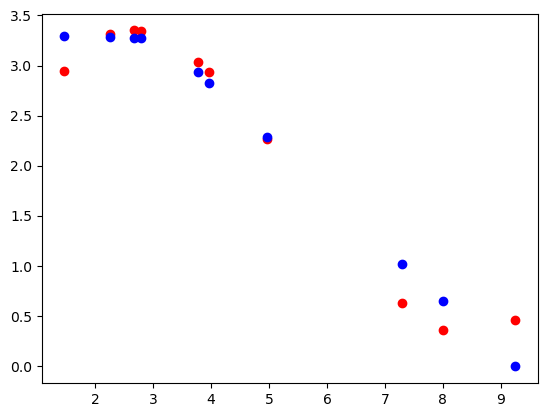

In [79]:
y_prediction_from_sample = []
for x in x_sample_standardized:
    input_vector = np.array([x])
    predicted_output = my_neural_network.forward(input_vector)
    y_prediction_from_sample.append(predicted_output[0] * y_sample_std + y_sample_mean) # de-standardize the predicted output
plt.scatter(x_sample, y_sample, color="red", label="Sampled Data")
plt.scatter(x_sample, y_prediction_from_sample, color="blue", label="Predictions from Sampled Data")

In [80]:
# Plot the predictions vs true values after training
x_test = np.linspace(-5, 20, 100)
y_test = (A + B * x_test + C * x_test**2 + D * x_test**3).round(2)
x_test_standardized = (x_test - x_sample_mean) / x_sample_std
y_predictions = []
for x in x_test_standardized:
    input_vector = np.array([x])
    predicted_output = my_neural_network.forward(input_vector)
    y_predictions.append(predicted_output[0] * y_sample_std + y_sample_mean) # unstandardize the prediction
    

(-5.0, 30.0)

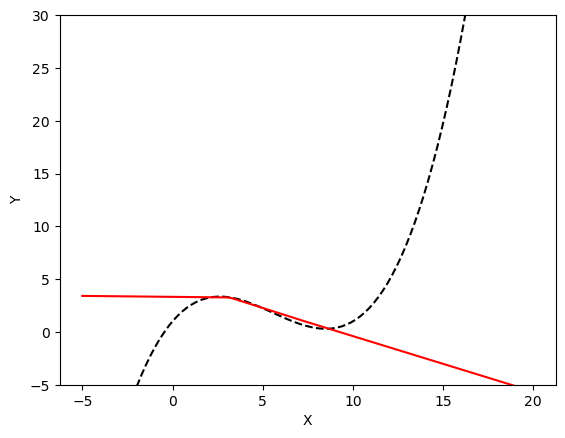

In [81]:
plt.plot(x_test, y_test, color="black", label="True Function", linestyle='--')
plt.plot(x_test, y_predictions, 'r-', label='Predictions')
plt.xlabel('X')
plt.ylabel('Y')
plt.ylim(-5, 30)

In [82]:
print_summary_of_network(
    Input_layer=input_layer_new, 
    Hidden_layer_1=hidden_layer_1_new, 
    Final_layer=final_layer_new
)

            Layer    Neuron               Weights      Bias  \
0     Input_layer  Neuron 1                   [1]       [0]   
1  Hidden_layer_1  Neuron 1               [-0.18]  0.188196   
2  Hidden_layer_1  Neuron 2               [-0.07]  0.072251   
3  Hidden_layer_1  Neuron 3                [0.98]  0.572323   
4     Final_layer  Neuron 1  [0.21, -0.01, -1.13]  0.769348   

  Activation Function      Input Vector   Output  
0              linear            [6.07]  6.07000  
1                relu            [6.07]  0.00000  
2                relu            [6.07]  0.00000  
3                relu            [6.07]  6.51989  
4              linear  [0.0, 0.0, 6.52] -6.56901  


In [83]:
import torch
import torch.nn as nn

In [57]:
model = nn.Sequential(
    nn.Linear(1, 3), 
    nn.ReLU(), 
    nn.Linear(3, 1)
)


In [58]:
# train the model on the same data for comparison
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
x_train = torch.from_numpy(x_sample.reshape(-1, 1)).float()
y_train = torch.from_numpy(y_sample.reshape(-1, 1)).float()
x_train_standardized = (x_train - x_sample_mean) / x_sample_std
y_train_standardized = (y_train - y_sample_mean) / y_sample_std
loss_history_torch = []
for epoch in range(1000):
    model.train()
    optimizer.zero_grad()
    outputs = model(x_train_standardized)
    loss = criterion(outputs, y_train_standardized)
    loss.backward()
    optimizer.step()
    loss_history_torch.append(loss.item())

    

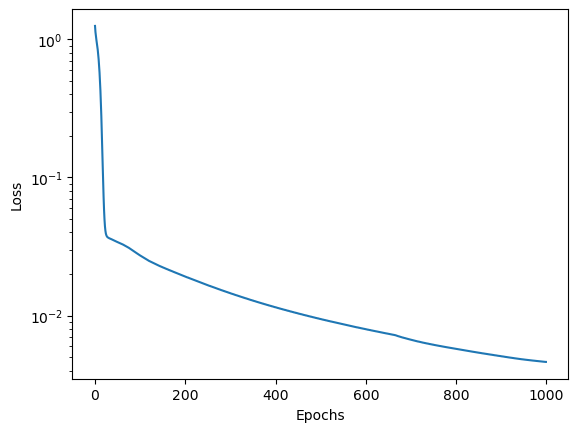

In [59]:
loss_history_torch = np.array(loss_history_torch)
plt.plot(loss_history_torch)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.yscale("log")

(-5.0, 30.0)

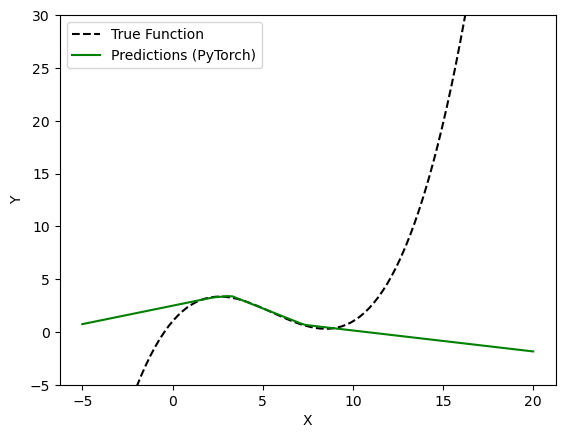

In [60]:
# Plot the predictions vs true values after training
x_test_torch = torch.from_numpy(x_test.reshape(-1, 1)).float()
x_test_standardized_torch = (x_test_torch - x_sample_mean) / x_sample_std
with torch.no_grad():
    y_predictions_standardized_torch = model(x_test_standardized_torch).numpy().flatten()
y_predictions_torch = y_predictions_standardized_torch * y_sample_std + y_sample_mean # unstandardize the predictions
plt.plot(x_test, y_test, color="black", label="True Function", linestyle='--')
plt.plot(x_test, y_predictions_torch, 'g-', label='Predictions (PyTorch)')
plt.legend()
plt.xlabel('X')
plt.ylabel('Y')
plt.ylim(-5, 30)


In [61]:
num_params = 64
model_complex = nn.Sequential(
    nn.Linear(1, num_params),
    nn.ReLU(),
    nn.Linear(num_params, 1)
)
criterion_complex = nn.MSELoss()
optimizer_complex = torch.optim.SGD(model_complex.parameters(), lr=0.01)
x_train_complex = torch.from_numpy(x_sample.reshape(-1, 1)).float()
y_train_complex = torch.from_numpy(y_sample.reshape(-1, 1)).float()
x_train_complex_standardized = (x_train_complex - x_sample_mean) / x_sample_std
y_train_complex_standardized = (y_train_complex - y_sample_mean) / y_sample_std


In [62]:
def train_model(model, criterion, optimizer, x_train, y_train, epochs):
    loss_history = []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(x_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())
    return model, np.array(loss_history)

In [63]:
model_complex_trained, loss_history_complex = train_model(model_complex, criterion_complex, optimizer_complex, x_train_complex_standardized, y_train_complex_standardized, epochs=5000)

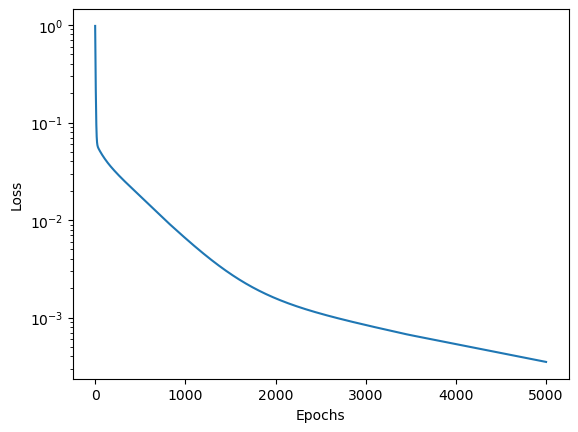

In [64]:
# Plot the loss history for the complex model
plt.plot(loss_history_complex)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.yscale("log")

Text(0, 0.5, 'Y')

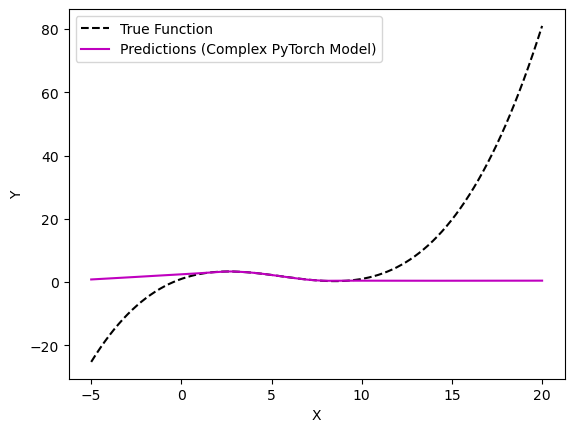

In [65]:
def predict(model, x_test, x_mean, x_std, y_mean, y_std):
    x_test_standardized = (x_test - x_mean) / x_std
    with torch.no_grad():
        y_predictions_standardized = model(torch.from_numpy(x_test_standardized.reshape(-1, 1)).float()).numpy().flatten()
    y_predictions = y_predictions_standardized * y_std + y_mean # unstandardize the predictions
    return y_predictions
y_predictions_complex = predict(model_complex_trained, x_test, x_sample_mean, x_sample_std, y_sample_mean, y_sample_std)
plt.plot(x_test, y_test, color="black", label="True Function", linestyle='--')
plt.plot(x_test, y_predictions_complex, 'm-', label='Predictions (Complex PyTorch Model)')
plt.legend()
plt.xlabel('X')
plt.ylabel('Y')


In [66]:
def train_multiple_times(model, x_test, n_runs=15):
    all_predictions = []
    for run in range(n_runs):
        # Re-initialize the model weights
        model.apply(lambda m: m.reset_parameters() if hasattr(m, 'reset_parameters') else None)
        # Train the model
        trained_model, _ = train_model(model, criterion_complex, optimizer_complex, x_train_complex_standardized, y_train_complex_standardized, epochs=5000)
        # Get predictions
        predictions = predict(trained_model, x_test, x_sample_mean, x_sample_std, y_sample_mean, y_sample_std)
        all_predictions.append(predictions)
    return np.array(all_predictions)
    

In [67]:
x_test_1 = np.linspace(-20, 20, 100)
y_test_1 = (A + B * x_test_1 + C * x_test_1**2 + D * x_test_1**3).round(2)

all_predictions = train_multiple_times(model_complex, x_test_1, n_runs=50)



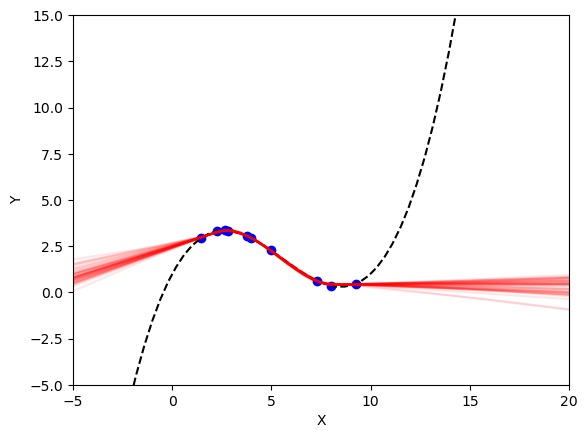

In [68]:
# Plot all predictions to show the variability due to different random initializations
plt.plot(x_test_1, y_test_1, color="black", label="True Function", linestyle='--')
for i in range(all_predictions.shape[0]):
    plt.plot(x_test_1, all_predictions[i], color="red", alpha=0.1)
plt.xlabel('X')
plt.ylabel('Y')
plt.ylim(-5, 15)
plt.xlim(-5, 20)
plt.scatter(x_sample, y_sample, color="blue", label="Sampled Data")

In [69]:
def polynomial_fit_many_times(x_sample, y_sample, noise_std, deg, x_test, n_runs=50):
    all_predictions = []
    for run in range(n_runs):
        # Fit a polynomial of the specified degree to the noisy samples
        x_sample_noisy = x_sample + np.random.normal(0, noise_std, size=x_sample.shape)
        y_sample_noisy = y_sample + np.random.normal(0, noise_std, size=y_sample.shape)
        coeffs = np.polyfit(x_sample_noisy, y_sample_noisy, deg)
        polynomial = np.poly1d(coeffs)
        predictions = polynomial(x_test)
        all_predictions.append(predictions)
    return np.array(all_predictions)


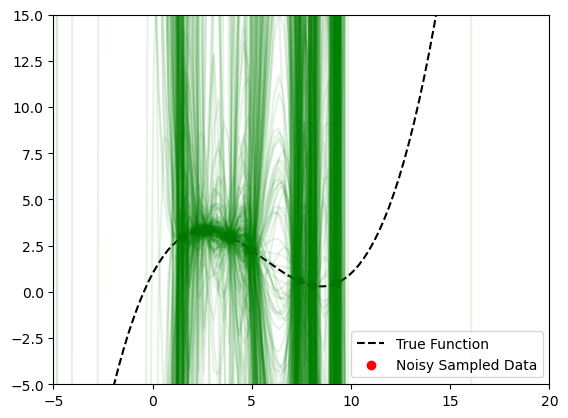

In [70]:
params = 10
noise_std = 0.2
y_polynomial_fit = polynomial_fit_many_times(\
    x_sample, y_sample, noise_std, deg=params, x_test=x_test, n_runs=200)

plt.plot(x_test, y_test, color="black", label="True Function", linestyle='--')
for i in range(y_polynomial_fit.shape[0]):
    plt.plot(x_test, y_polynomial_fit[i], color="green", alpha=0.1)
plt.scatter(x_sample, y_sample, color="red", label="Noisy Sampled Data")
plt.ylim(-5, 15)
plt.xlim(-5, 20)
plt.legend()


In [71]:
# Fit neural network with many parameters to noisy data
def train_nn_with_noisy_data_many_times(x_sample, y_sample, noise_std, x_test, num_neurons, n_runs=50):
    all_predictions = []
    x_noisy_sample = x_sample + np.random.normal(0, noise_std, size=x_sample.shape)
    y_noisy_sample = y_sample + np.random.normal(0, noise_std, size=y_sample.shape)
    x_sample_mean, x_sample_std = np.mean(x_noisy_sample), np.std(x_noisy_sample)
    y_sample_mean, y_sample_std = np.mean(y_noisy_sample), np.std(y_noisy_sample)
    for run in range(n_runs):
        x_sample_noisy_standardized = (x_noisy_sample - x_sample_mean) / x_sample_std
        y_sample_noisy_standardized = (y_noisy_sample - y_sample_mean) / y_sample_std
        # Create a new model instance with the specified number of neurons
        model = nn.Sequential(
            nn.Linear(1, num_neurons),
            nn.ReLU(),
            nn.Linear(num_neurons, 1)
        )
        criterion = nn.MSELoss()
        optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
        
        # Train the model on the noisy data
        x_train = torch.from_numpy(x_sample_noisy_standardized.reshape(-1, 1)).float()
        y_train = torch.from_numpy(y_sample_noisy_standardized.reshape(-1, 1)).float()
        train_model(model, criterion, optimizer, x_train, y_train, epochs=5000)
        
        # Get predictions on the test set
        predictions = predict(model, x_test, x_sample_mean, x_sample_std, y_sample_mean, y_sample_std)
        all_predictions.append(predictions)
    return np.array(all_predictions)

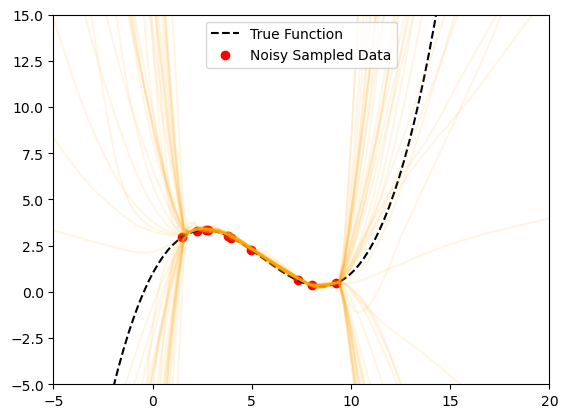

In [72]:
num_neurons = 1000
all_nn_predictions_noisy = train_nn_with_noisy_data_many_times(
    x_sample, y_sample, noise_std, x_test, num_neurons=num_neurons, n_runs=50)

plt.plot(x_test, y_test, color="black", label="True Function", linestyle='--')
for i in range(all_nn_predictions_noisy.shape[0]):
    plt.plot(x_test, all_nn_predictions_noisy[i], color="orange", alpha=0.1)
plt.scatter(x_sample, y_sample, color="red", label="Noisy Sampled Data")
plt.ylim(-5, 15)
plt.xlim(-5, 20)
plt.legend()



(-5.0, 20.0)

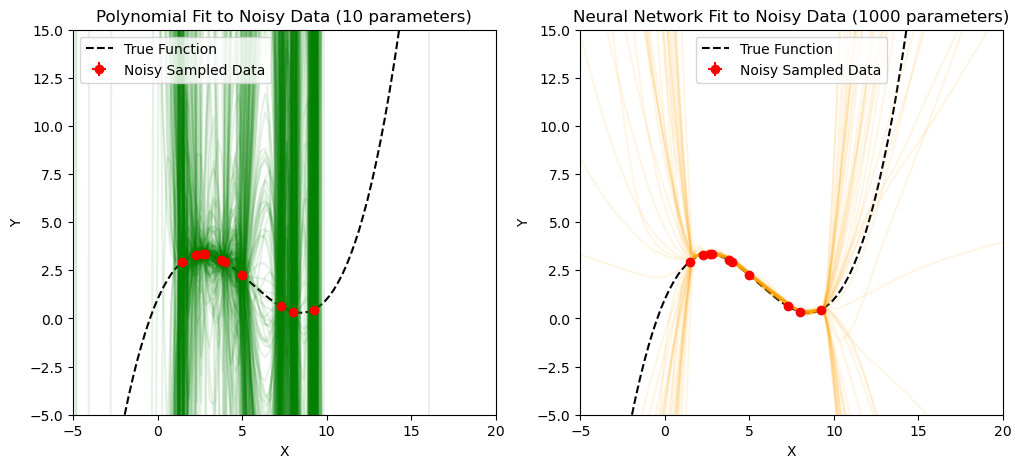

In [73]:
# Compare polynomial fit and neural network fit on the same noisy data with more parameters
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(x_test, y_test, color="black", label="True Function", linestyle='--')
for i in range(y_polynomial_fit.shape[0]):
    ax[0].plot(x_test, y_polynomial_fit[i], color="green", alpha=0.1)
ax[0].errorbar(
    x_sample, y_sample, xerr=noise_std, yerr=noise_std, fmt='o', color="red", label="Noisy Sampled Data")
ax[0].set_title("Polynomial Fit to Noisy Data ({} parameters)".format(params))
ax[0].set_xlabel('X')
ax[0].set_ylabel('Y')
ax[0].legend()
ax[0].set_ylim(-5, 15)
ax[0].set_xlim(-5, 20)
ax[1].plot(x_test, y_test, color="black", label="True Function", linestyle='--')
for i in range(all_nn_predictions_noisy.shape[0]):
    ax[1].plot(x_test, all_nn_predictions_noisy[i], color="orange", alpha=0.1)
ax[1].errorbar(
    x_sample, y_sample, xerr=noise_std, yerr=noise_std, fmt='o', color="red", label="Noisy Sampled Data")
ax[1].set_title("Neural Network Fit to Noisy Data ({} parameters)".format(num_neurons))
ax[1].set_xlabel('X')
ax[1].set_ylabel('Y')
ax[1].legend()
ax[1].set_ylim(-5, 15)
ax[1].set_xlim(-5, 20)

    